# Limpieza y Análisis Inicial de Datos
Dataset: Netflix Movies and TV Shows (Kaggle)


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

df = pd.read_csv("netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## Diagnóstico rápido de calidad

In [17]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [18]:
# Conteo de valores faltantes por columna
df.isna().sum().sort_values(ascending=False)

director        2634
country          831
cast             825
date_added        10
rating             4
duration           3
show_id            0
type               0
title              0
release_year       0
listed_in          0
description        0
dtype: int64

In [19]:
# Duplicados
df.duplicated().sum()

np.int64(0)

In [20]:
df.isnull().sum()


show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

Se identifican valores faltantes principalmente en las columnas:
- director
- cast
- country
- date_added
- rating
- duration

No se detectan duplicados.


In [21]:
df = df.drop_duplicates()


Se eliminaron registros duplicados para garantizar consistencia en el dataset.


In [23]:
df["director"] = df["director"].fillna("Unknown")
df["cast"] = df["cast"].fillna("Unknown")
df["country"] = df["country"].fillna("Not Specified")
df["rating"] = df["rating"].fillna("Not Rated")
df["duration"] = df["duration"].fillna("Not Available")

In [25]:

df["date_added"] = df["date_added"].str.strip()
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")


In [26]:
df["date_added"].isnull().sum()


np.int64(10)

La columna `date_added` presenta 10 valores faltantes que ya existían en el dataset original. 
Estos registros se mantienen como NaT después de la conversión a datetime.


### Estandarización de datos

In [27]:
df.dtypes


show_id                    str
type                       str
title                      str
director                   str
cast                       str
country                    str
date_added      datetime64[us]
release_year             int64
rating                     str
duration                   str
listed_in                  str
description                str
dtype: object

In [29]:
text_columns = df.select_dtypes(include=["object", "string"]).columns

for col in text_columns:
    df[col] = df[col].str.strip()



In [30]:
df["type"] = df["type"].str.lower()


In [31]:
df["country"] = df["country"].str.title()


In [32]:
df["director"] = df["director"].str.title()
df["cast"] = df["cast"].str.title()


In [33]:
df["rating"] = df["rating"].str.upper()


In [34]:
import re

for col in text_columns:
    df[col] = df[col].apply(lambda x: re.sub(r"\s+", " ", x) if isinstance(x, str) else x)


In [35]:
df.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,tv show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,tv show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Not Specified,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,tv show,Jailbirds New Orleans,Unknown,Unknown,Not Specified,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,tv show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


Se aplicaron las siguientes transformaciones:

- Eliminación de espacios en blanco al inicio y final.
- Normalización de texto (minúsculas y formato título según columna).
- Unificación del formato de clasificación (rating).
- Corrección de espacios múltiples internos.

Estas acciones mejoran la consistencia y calidad del dataset para análisis posterior.


In [36]:
pivot_type = pd.pivot_table(
    df,
    values="show_id",
    index="type",
    aggfunc="count"
)

pivot_type


,show_id
type,
movie,6131
tv show,2676


In [37]:
pivot_type = pivot_type.rename(columns={"show_id": "cantidad_titulos"})
pivot_type


,cantidad_titulos
type,
movie,6131
tv show,2676


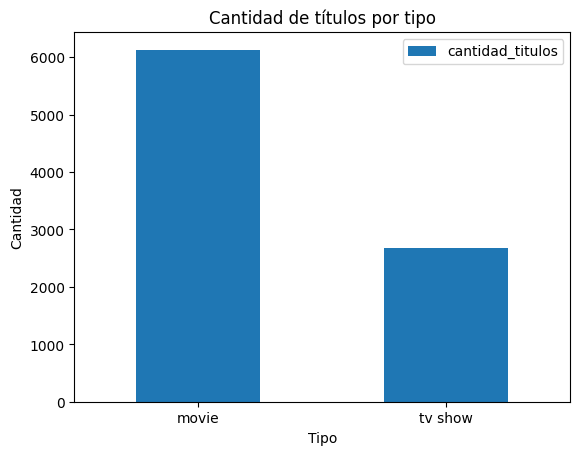

In [38]:
pivot_type.plot(kind="bar")
plt.title("Cantidad de títulos por tipo")
plt.ylabel("Cantidad")
plt.xlabel("Tipo")
plt.xticks(rotation=0)
plt.show()


### Interpretación

La tabla pivote muestra la cantidad total de títulos disponibles en Netflix clasificados por tipo.

Se observa que existe una mayor cantidad de películas en comparación con series, lo cual indica que la plataforma tiene una oferta predominante de contenido cinematográfico.

Este análisis permite comprender la distribución general del contenido dentro del dataset.


In [39]:
pivot_year = pd.pivot_table(
    df,
    values="show_id",
    index="release_year",
    aggfunc="count"
)

pivot_year.tail()


,show_id
release_year,
2017,1032
2018,1147
2019,1030
2020,953
2021,592


### Exportación del Dataset Limpio

El dataset procesado fue exportado en formato CSV con el nombre `dataset_limpio.csv`, garantizando que las transformaciones aplicadas queden almacenadas para futuros análisis.


In [40]:
df.to_csv("dataset_limpio.csv", index=False)
